<a href="https://colab.research.google.com/github/dekeu/telco_customer_churn_analysis/blob/main/telco_customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Data Cleaning**

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [10]:
df = df.dropna(subset=['TotalCharges'])

# **Exploratory Data Analysis (Customer Churn)**

In [17]:
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate*100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [18]:
contract_churn = (
    df
    .groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .unstack()
)
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


<Axes: title={'center': 'Churn Rate by Contract'}, xlabel='Contract'>

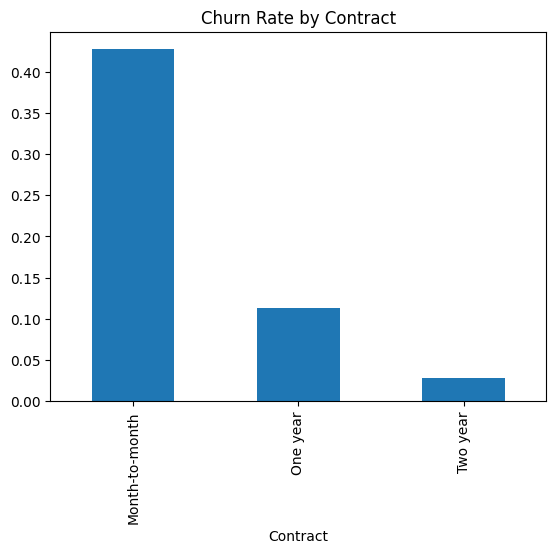

In [19]:
contract_churn['Yes'].plot(kind='bar', title='Churn Rate by Contract')

In [21]:
df['tenure'].describe()

,tenure
count,7032.000000
mean,32.421786
std,24.545260
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [22]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins = [0, 12, 24, 36, 48, 72],
    labels = ['0-12', '12-24', '24-36', '36-48', '49+']
)

In [24]:
tenure_churn = (
    df
    .groupby('tenure_group')['Churn']
    .value_counts(normalize=True)
    .unstack()
)
tenure_churn

/tmp/ipython-input-2501484721.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tenure_group')['Churn']


Churn,No,Yes
tenure_group,,
0-12,0.523218,0.476782
12-24,0.712891,0.287109
24-36,0.783654,0.216346
36-48,0.809711,0.190289
49+,0.904868,0.095132


<Axes: title={'center': 'Churn Rate by Tenure'}, xlabel='tenure_group'>

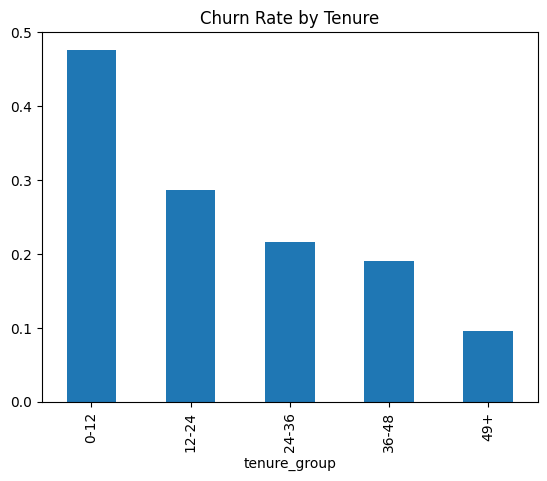

In [25]:
tenure_churn['Yes'].plot(kind='bar', title='Churn Rate by Tenure')

In [26]:
payment_churn = (
    df
    .groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .unstack()
)
payment_churn['Yes'].sort_values(ascending=False)

,Yes
PaymentMethod,
Electronic check,0.452854
Mailed check,0.192020
Bank transfer (automatic),0.167315
Credit card (automatic),0.152531
